In [2]:
import pandas as pd

# Load the raw orders and products data
orders = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

# Inspect the orders data
print("ORDERS INFO")
orders.info()

print("\nORDERS DESCRIPTIVE STATISTICS")
display(orders.describe(include="all"))

print("\nORDER STATUS COUNTS")
print(orders["status"].value_counts())

# Inspect the products data
print("\nPRODUCTS INFO")
products.info()

print("\nPRODUCTS PREVIEW")
display(products.head())

ORDERS INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB

ORDERS DESCRIPTIVE STATISTICS


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
count,508.000000,508,508,508,508,508.000000,508.000000,498.000000,508,508,439.000000
unique,NaN,165,50,14,18,NaN,NaN,NaN,5,3,NaN
top,NaN,2026-04-16,Arjun,Mumbai,Household Essentials,NaN,NaN,NaN,Wallet,Delivered,NaN
freq,NaN,10,19,133,94,NaN,NaN,NaN,111,439,NaN
mean,250.204724,NaN,NaN,NaN,NaN,15.476378,3.045276,257.530120,NaN,NaN,3.082005
std,144.594139,NaN,NaN,NaN,NaN,8.747467,1.364497,559.424136,NaN,NaN,1.364126
min,1.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,20.000000,NaN,NaN,1.000000
25%,125.750000,NaN,NaN,NaN,NaN,8.000000,2.000000,90.000000,NaN,NaN,2.000000
50%,249.500000,NaN,NaN,NaN,NaN,15.000000,3.000000,168.000000,NaN,NaN,3.000000
75%,376.250000,NaN,NaN,NaN,NaN,23.000000,4.000000,283.750000,NaN,NaN,4.000000



ORDER STATUS COUNTS
status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64

PRODUCTS INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   product_id      31 non-null     int64 
 1   product_name    31 non-null     object
 2   category        31 non-null     object
 3   supplier        31 non-null     object
 4   unit_price_inr  31 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 1.3+ KB

PRODUCTS PREVIEW


,product_id,product_name,category,supplier,unit_price_inr
0,1,Banana 1kg,Fruits & Vegetables,FreshFarms Co,50
1,2,Tomato 1kg,Fruits & Vegetables,FreshFarms Co,40
2,3,Onion 1kg,Fruits & Vegetables,GreenValley Traders,35
3,4,Apple 1kg,Fruits & Vegetables,GreenValley Traders,180
4,5,Spinach Bunch,Fruits & Vegetables,FreshFarms Co,25


## Task 1 — Initial Data Inspection

The raw orders file contains 508 rows, which is more than the expected 500 rows and indicates that duplicate records are present.

The initial inspection also shows inconsistent formatting in the city and category columns that will need to be cleaned. There are 10 missing values in amount_inr, along with some unusually large amount values that will need to be investigated as potential outliers.

The status column contains Delivered, Cancelled, and Pending orders. Missing rating values are expected for Cancelled and Pending orders because ratings are only recorded for Delivered orders.


In [3]:
# Task 2 — Remove duplicate order_id records

# Count duplicate rows based on order_id
duplicate_count = orders["order_id"].duplicated().sum()

print("Duplicate rows found:", duplicate_count)

# Remove duplicates, keeping the first occurrence
orders_clean = orders.drop_duplicates(subset="order_id", keep="first").copy()

print("Rows after removing duplicates:", len(orders_clean))
print("Rows removed:", len(orders) - len(orders_clean))

Duplicate rows found: 8
Rows after removing duplicates: 500
Rows removed: 8


## Task 2 — Duplicate Removal

The raw dataset contained **8 duplicate order_id records**. I removed the duplicate records while keeping the first occurrence of each order_id.

This reduced the dataset from **508 rows to exactly 500 rows**, as expected.

In [4]:
# Task 3 — Fix casing and whitespace

# Clean city and category text
orders_clean["city"] = orders_clean["city"].str.strip().str.title()
orders_clean["category"] = orders_clean["category"].str.strip().str.title()

# Print distinct values as proof
print("Distinct cities:")
print(sorted(orders_clean["city"].dropna().unique()))

print("\nNumber of distinct cities:", orders_clean["city"].nunique())

print("\nDistinct categories:")
print(sorted(orders_clean["category"].dropna().unique()))

print("\nNumber of distinct categories:", orders_clean["category"].nunique())

Distinct cities:
['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']

Number of distinct cities: 4

Distinct categories:
['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']

Number of distinct categories: 6


## Task 3 — Casing and Whitespace Cleaning

The city and category columns were cleaned using `.str.strip()` to remove unwanted whitespace and `.str.title()` to standardize capitalization.

After cleaning, the city column contains exactly **4 distinct values**: Bengaluru, Hyderabad, Mumbai, and Pune.

The category column contains exactly **6 distinct values**, matching the canonical categories used throughout the project.

In [5]:
# Task 4 — Handle missing values

# Count missing amount values
missing_amount = orders_clean["amount_inr"].isna().sum()

# Count missing rating values
missing_rating = orders_clean["rating"].isna().sum()

print("Missing amount_inr values:", missing_amount)
print("Missing rating values:", missing_rating)

# Checking rating missingness by order status
print("\nMissing ratings by status:")
print(
    orders_clean.groupby("status")["rating"]
    .apply(lambda x: x.isna().sum())
)

# Checking how many non-Delivered orders have a missing rating
non_delivered = orders_clean["status"] != "Delivered"
missing_rating_non_delivered = (
    orders_clean.loc[non_delivered, "rating"].isna().sum()
)

print(
    "\nMissing ratings among non-Delivered orders:",
    missing_rating_non_delivered
)

# Checking whether any Delivered orders have a missing rating
delivered = orders_clean["status"] == "Delivered"
missing_rating_delivered = (
    orders_clean.loc[delivered, "rating"].isna().sum()
)

print(
    "Missing ratings among Delivered orders:",
    missing_rating_delivered
)

Missing amount_inr values: 10
Missing rating values: 66

Missing ratings by status:
status
Cancelled    42
Delivered     0
Pending      24
Name: rating, dtype: int64

Missing ratings among non-Delivered orders: 66
Missing ratings among Delivered orders: 0


## Task 4 — Missing Value Handling

There are **10 missing values in `amount_inr`**. These values are left as missing rather than being replaced with 0 or the mean because the actual revenue for these orders is unknown. These rows will therefore be excluded from revenue calculations.

There are **66 missing values in `rating`**. These are expected because ratings are only recorded for Delivered orders. The missing ratings for Cancelled and Pending orders are therefore left unchanged and are not treated as a data-quality issue.

In [6]:
# Task 5 — Detect and cap outliers using IQR

# Use only Delivered orders with a known amount
delivered_amounts = orders_clean.loc[
    (orders_clean["status"] == "Delivered") &
    (orders_clean["amount_inr"].notna()),
    "amount_inr"
]

# Calculate Q1 and Q3
Q1 = delivered_amounts.quantile(0.25)
Q3 = delivered_amounts.quantile(0.75)

# Calculate IQR and upper fence
IQR = Q3 - Q1
upper_fence = Q3 + (1.5 * IQR)

# Count values above the upper fence
outlier_count = (delivered_amounts > upper_fence).sum()

print("Q1 (25th percentile):", Q1)
print("Q3 (75th percentile):", Q3)
print("IQR:", IQR)
print("Upper fence:", upper_fence)
print("Number of values above upper fence:", outlier_count)

# Create a capped amount column
orders_clean["capped_amount_inr"] = orders_clean["amount_inr"].clip(
    upper=upper_fence
)

# Count how many rows were actually capped
capped_count = (
    (orders_clean["status"] == "Delivered") &
    (orders_clean["amount_inr"].notna()) &
    (orders_clean["amount_inr"] > upper_fence)
).sum()

print("Number of Delivered rows capped:", capped_count)

Q1 (25th percentile): 90.0
Q3 (75th percentile): 275.0
IQR: 185.0
Upper fence: 552.5
Number of values above upper fence: 16
Number of Delivered rows capped: 16


## Task 5 — IQR Outlier Detection and Capping

For Delivered orders with non-null `amount_inr`, I calculated Q1 (25th percentile) and Q3 (75th percentile) using `.quantile()`.

The IQR was calculated as:

**IQR = Q3 - Q1**

The upper outlier fence was calculated as:

**Upper Fence = Q3 + 1.5 × IQR**

Values above the upper fence were treated as high-side outliers. Instead of removing these orders, I capped their values at the upper fence using `.clip()`. This keeps the orders in the dataset while reducing the influence of unusually large values on the revenue analysis.

In [7]:
# Task 6 — Parse dates and create derived columns

# Convert order_date to datetime
orders_clean["order_date"] = pd.to_datetime(orders_clean["order_date"])

# Extract month number
orders_clean["month"] = orders_clean["order_date"].dt.month

# Extract month name
orders_clean["month_name"] = orders_clean["order_date"].dt.month_name()

# Calculate revenue per unit using the capped amount
orders_clean["revenue_per_unit"] = (
    orders_clean["capped_amount_inr"] / orders_clean["quantity"]
)

# Create Delivered flag
orders_clean["is_delivered"] = orders_clean["status"] == "Delivered"

# Display a few rows to verify the new columns
display(
    orders_clean[
        [
            "order_date",
            "month",
            "month_name",
            "amount_inr",
            "capped_amount_inr",
            "quantity",
            "revenue_per_unit",
            "status",
            "is_delivered"
        ]
    ].head()
)

,order_date,month,month_name,amount_inr,capped_amount_inr,quantity,revenue_per_unit,status,is_delivered
0,2026-03-09,3,March,175.0,175.0,5,35.0,Delivered,True
1,2026-05-22,5,May,60.0,60.0,1,60.0,Delivered,True
2,2026-06-30,6,June,150.0,150.0,2,75.0,Delivered,True
3,2026-03-01,3,March,30.0,30.0,1,30.0,Delivered,True
4,2026-04-05,4,April,220.0,220.0,2,110.0,Delivered,True


## Task 6 — Dates and Derived Columns

The `order_date` column was converted to datetime using `pd.to_datetime()`.

Two date-based columns were created:
- `month` contains the numeric month.
- `month_name` contains the month name.

A `revenue_per_unit` column was created by dividing the capped order amount by quantity.

An `is_delivered` Boolean column was also created to identify Delivered orders directly from the order status.

In [8]:
# Task 7 — Business analysis and cross-validation

# Keep only Delivered orders with known revenue
delivered_clean = orders_clean[
    (orders_clean["status"] == "Delivered") &
    (orders_clean["capped_amount_inr"].notna())
].copy()

# --------------------------------------------------
# 7A — Revenue by Category
# --------------------------------------------------

category_revenue = (
    delivered_clean
    .groupby("category")["capped_amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print("Revenue by Category:")
display(category_revenue.to_frame(name="total_revenue"))

top_category = category_revenue.idxmax()
top_category_revenue = category_revenue.max()

print("Top category by revenue:", top_category)
print("Top category revenue:", top_category_revenue)


# --------------------------------------------------
# 7B — Merge with Products and find Top Supplier
# --------------------------------------------------

orders_with_products = delivered_clean.merge(
    products[["product_id", "supplier"]],
    on="product_id",
    how="left"
)

supplier_revenue = (
    orders_with_products
    .groupby("supplier")["capped_amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print("\nRevenue by Supplier:")
display(supplier_revenue.to_frame(name="total_revenue"))

top_supplier = supplier_revenue.idxmax()
top_supplier_revenue = supplier_revenue.max()

print("Top supplier by revenue:", top_supplier)
print("Top supplier revenue:", top_supplier_revenue)


# --------------------------------------------------
# 7C — Cross-validation with Part 1
# --------------------------------------------------

print("\nCross-validation with Part 1 SQL findings:")
print("Top category from Part 1 SQL: Household Essentials")
print("Top supplier from Part 1 SQL: HomeEssentials Traders")

print(
    "Category match:",
    top_category == "Household Essentials"
)

print(
    "Supplier match:",
    top_supplier == "HomeEssentials Traders"
)

Revenue by Category:


,total_revenue
category,
Household Essentials,20910.0
Bakery,14975.0
Personal Care,14594.5
Dairy & Eggs,13675.0
Snacks & Beverages,11312.5
Fruits & Vegetables,9170.0


Top category by revenue: Household Essentials
Top category revenue: 20910.0

Revenue by Supplier:


,total_revenue
supplier,
HomeEssentials Traders,20910.0
BakeHouse Supplies,18550.0
CarePlus Distributors,14594.5
DairyBest Ltd,10710.0
SnackHub India,7737.5
FreshFarms Co,5490.0
GreenValley Traders,3680.0
CountryEggs Farms,2965.0


Top supplier by revenue: HomeEssentials Traders
Top supplier revenue: 20910.0

Cross-validation with Part 1 SQL findings:
Top category from Part 1 SQL: Household Essentials
Top supplier from Part 1 SQL: HomeEssentials Traders
Category match: True
Supplier match: True


## Task 7 — Business Questions and Cross-Validation

### 7A — Top Category

The cleaned and capped Delivered-order data was grouped by category to calculate total revenue.

The top category by revenue is **Household Essentials**.

### 7B — Top Supplier

The cleaned orders were merged with `products.csv` using `product_id`. The merged data was then grouped by supplier to calculate total revenue.

The top supplier by revenue is **HomeEssentials Traders**.

### 7C — Cross-Validation with Part 1

The Part 4 results match the key findings from Part 1:

- Top category: **Household Essentials**
- Top supplier: **HomeEssentials Traders**

The exact revenue values are different from Part 1 because Part 4 starts with the raw data and applies duplicate removal, missing-value exclusions, and IQR-based outlier capping. The important category and supplier rankings still agree, which confirms that the cleaning and analysis pipeline is working correctly.

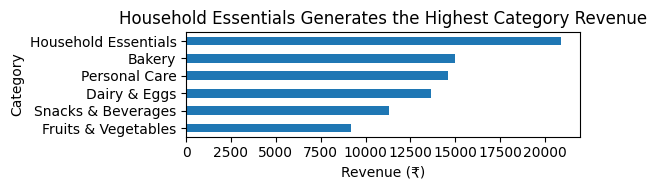

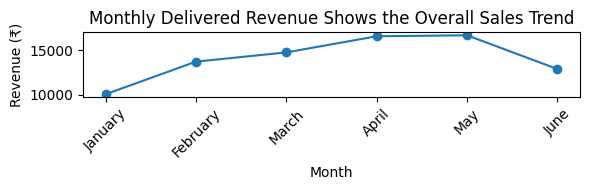

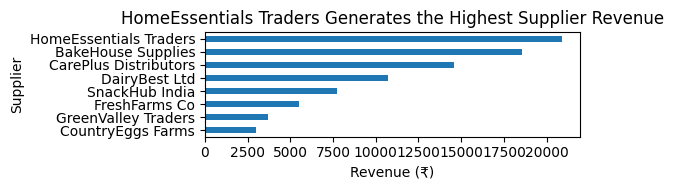

In [10]:
# Task 8 — Visualize the cleaned and capped data

import matplotlib.pyplot as plt


# Chart 1 — Category Revenue


category_revenue = (
    delivered_clean
    .groupby("category")["capped_amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(6, 2))
category_revenue.plot(kind="barh")

plt.title("Household Essentials Generates the Highest Category Revenue")
plt.xlabel("Revenue (₹)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()



# Chart 2 — Monthly Revenue Trend


monthly_revenue = (
    delivered_clean
    .groupby("month")["capped_amount_inr"]
    .sum()
)

month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June"
}

monthly_revenue.index = monthly_revenue.index.map(month_names)

plt.figure(figsize=(6, 2))
monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Delivered Revenue Shows the Overall Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Chart 3 — Supplier Revenue


supplier_revenue = (
    orders_with_products
    .groupby("supplier")["capped_amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(6, 2))
supplier_revenue.plot(kind="barh")

plt.title("HomeEssentials Traders Generates the Highest Supplier Revenue")
plt.xlabel("Revenue (₹)")
plt.ylabel("Supplier")
plt.tight_layout()
plt.show()

## Task 8 — Visualizations

Three Matplotlib visualizations were created using the cleaned and capped Delivered-order data.

1. A category revenue bar chart shows that **Household Essentials generates the highest revenue**.
2. A monthly revenue line chart shows the **overall trend in Delivered revenue across the six months**.
3. A supplier revenue bar chart shows that **HomeEssentials Traders generates the highest supplier revenue**.

Each chart has a finding-based title and labelled axes.

In [11]:
# Task 9 — Get exact numbers for the insight write-up

# Category performance
category_summary = (
    delivered_clean
    .groupby("category")["capped_amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

# Supplier performance
supplier_summary = (
    orders_with_products
    .groupby("supplier")["capped_amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

# Monthly performance
monthly_summary = (
    delivered_clean
    .groupby("month")["capped_amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print("CATEGORY REVENUE")
display(category_summary)

print("\nTOP CATEGORY")
print(category_summary.index[0], "— ₹", round(category_summary.iloc[0], 2))

print("\nLOWEST CATEGORY")
print(category_summary.index[-1], "— ₹", round(category_summary.iloc[-1], 2))

print("\nTOP SUPPLIER")
print(supplier_summary.index[0], "— ₹", round(supplier_summary.iloc[0], 2))

print("\nHIGHEST REVENUE MONTH")
print(
    month_names[monthly_summary.index[0]],
    "— ₹",
    round(monthly_summary.iloc[0], 2)
)

CATEGORY REVENUE


,capped_amount_inr
category,
Household Essentials,20910.0
Bakery,14975.0
Personal Care,14594.5
Dairy & Eggs,13675.0
Snacks & Beverages,11312.5
Fruits & Vegetables,9170.0



TOP CATEGORY
Household Essentials — ₹ 20910.0

LOWEST CATEGORY
Fruits & Vegetables — ₹ 9170.0

TOP SUPPLIER
HomeEssentials Traders — ₹ 20910.0

HIGHEST REVENUE MONTH
May — ₹ 16668.5


## Task 9 — Business Insights

### Insight 1 — Household Essentials is the strongest category

**What:** Household Essentials generated the highest revenue at **₹20,910**, while Fruits & Vegetables generated the lowest at **₹9,170**.

**Why it matters:** The gap between the highest and lowest category is **₹11,740**, showing a clear difference in category-level revenue performance.

**Next step:** Continue monitoring Household Essentials as the strongest category and focus additional analysis on why Fruits & Vegetables is generating significantly less revenue.

---

### Insight 2 — HomeEssentials Traders is the top supplier

**What:** HomeEssentials Traders generated the highest supplier revenue at **₹20,910**.

**Why it matters:** The supplier's revenue is equal to the total revenue generated by the Household Essentials category, making it the strongest supplier in the cleaned dataset.

**Next step:** Track HomeEssentials Traders' performance in future periods and compare its revenue contribution with the other suppliers.

---

### Insight 3 — May had the highest monthly revenue

**What:** May recorded the highest Delivered revenue at **₹16,668.50** among the six months analyzed.

**Why it matters:** May represents the strongest monthly revenue performance in the cleaned and capped dataset.

**Next step:** Compare May with the other months in the dashboard to identify whether this higher revenue is part of a broader trend or a one-month peak.